# MLP Classification #
Arhan Erdogan

#### Imports ####

In [69]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#### Loaded cleaned dataset ####

In [70]:
script_dir = os.getcwd()
rel_path = "intermediate"

dataset = pd.read_csv(os.path.join(script_dir, rel_path, "CLEAN_data_injection_moulding.csv"))

#### Feature selection might change ####

Excluding cycle time (ZUs) as it dominates the model. Selected features include are injection time (ZSx), cushion volume (ACPx), dosing time (ZDx), ejection time (ZEx), energy consumption (GEx) and temperature measures (H16x and H10x).

In [71]:
# features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'GEx [kWh]', 'H16x [°C]', 'H10x [°C]']
#ZUs [s] excluded, with it F1: 0.95
features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'APHu [bar]', 'GEx [kWh]', 'GPx [kW]', 'HPx [kW]', 'HEx [kWh]', 'MPx [kW]', 'ESPx [kWh/kg]', 'H16x [°C]', 'H15x [°C]', 'H10x [°C]', 'H12x [°C]', 'H9x [°C]', 'H11x [°C]']

X = dataset[features]
y = dataset['ASZ [Sch]']

#### Splitting and Scaling Data ####

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Training MLP basic and without balancing ####

In [73]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(128,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


#### Evaluate Basic Model ####

In [74]:
y_pred = mlp.predict(X_test_scaled)


print(classification_report(y_test, y_pred))
mlp_cr = classification_report(y_test, y_pred,output_dict=True)



              precision    recall  f1-score   support

           0       0.99      1.00      0.99       933
           1       0.91      0.82      0.86        38

    accuracy                           0.99       971
   macro avg       0.95      0.91      0.93       971
weighted avg       0.99      0.99      0.99       971



#### Plot Confusion Matrix (Basic Model) ####

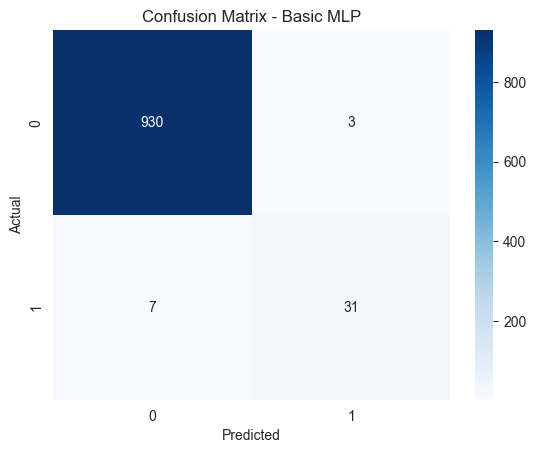

In [75]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Basic MLP')
plt.show()

#### Apply SMOTE to Handle Class Imbalance ####

The dataset has severe class imbalance (~933 good parts vs ~38 scrap). We use SMOTE to oversample the minority class in the training data.

In [76]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {sum(y_train == 1)} scrap samples')
print(f'After SMOTE: {sum(y_train_res == 1)} scrap samples')

Before SMOTE: 125 scrap samples
After SMOTE: 3758 scrap samples


#### Train MLP with Balanced Data ####

In [77]:
mlp_balanced = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
)

mlp_balanced.fit(X_train_res, y_train_res)



,hidden_layer_sizes,"(128,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


#### Evaluate Balanced Model ####

In [78]:
y_pred_balanced = mlp_balanced.predict(X_test_scaled)
print(classification_report(y_test, y_pred_balanced))

mlp_balanced_cr = classification_report(y_test, y_pred_balanced,output_dict=True)

print(type(mlp_balanced_cr))

#store the crs
%store mlp_cr mlp_balanced_cr

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       933
           1       0.82      0.95      0.88        38

    accuracy                           0.99       971
   macro avg       0.91      0.97      0.94       971
weighted avg       0.99      0.99      0.99       971

<class 'dict'>
Stored 'mlp_cr' (dict)
Stored 'mlp_balanced_cr' (dict)


#### Plot Confusion Matrix (Balanced Model) ####

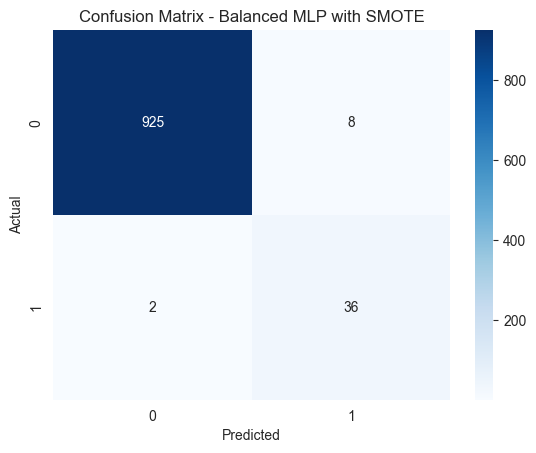

In [79]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Balanced MLP with SMOTE')
plt.show()

#### Hyperparameter Tuning - Testing Different Architectures ####

We test different hidden layer configurations to find the optimal architecture.

In [80]:
architectures = [
    (32,),
    (64,),
    (128,),
    (64, 32),
    (100, 50),
    (128, 64, 32)
]

results = []

for arch in architectures:
    mlp_test = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
    )
    
    mlp_test.fit(X_train_res, y_train_res)
    y_pred_test = mlp_test.predict(X_test_scaled)
    
    report = classification_report(y_test, y_pred_test, output_dict=True)
    
    results.append({
        'architecture': arch,
        'accuracy': report['accuracy'],
        'scrap_precision': report['1']['precision'],
        'scrap_recall': report['1']['recall'],
        'scrap_f1': report['1']['f1-score']
    })
    
    print(f"Architecture {arch}:")
    print(f"  Accuracy: {report['accuracy']:.3f}")
    print(f"  Scrap Recall: {report['1']['recall']:.3f}")
    print(f"  Scrap F1: {report['1']['f1-score']:.3f}")
    print()

Architecture (32,):
  Accuracy: 0.986
  Scrap Recall: 0.921
  Scrap F1: 0.833

Architecture (64,):
  Accuracy: 0.987
  Scrap Recall: 0.921
  Scrap F1: 0.843

Architecture (128,):
  Accuracy: 0.990
  Scrap Recall: 0.947
  Scrap F1: 0.878

Architecture (64, 32):
  Accuracy: 0.987
  Scrap Recall: 0.868
  Scrap F1: 0.835

Architecture (100, 50):
  Accuracy: 0.988
  Scrap Recall: 0.868
  Scrap F1: 0.846

Architecture (128, 64, 32):
  Accuracy: 0.990
  Scrap Recall: 0.868
  Scrap F1: 0.868



#### Visualize Architecture Performance ####

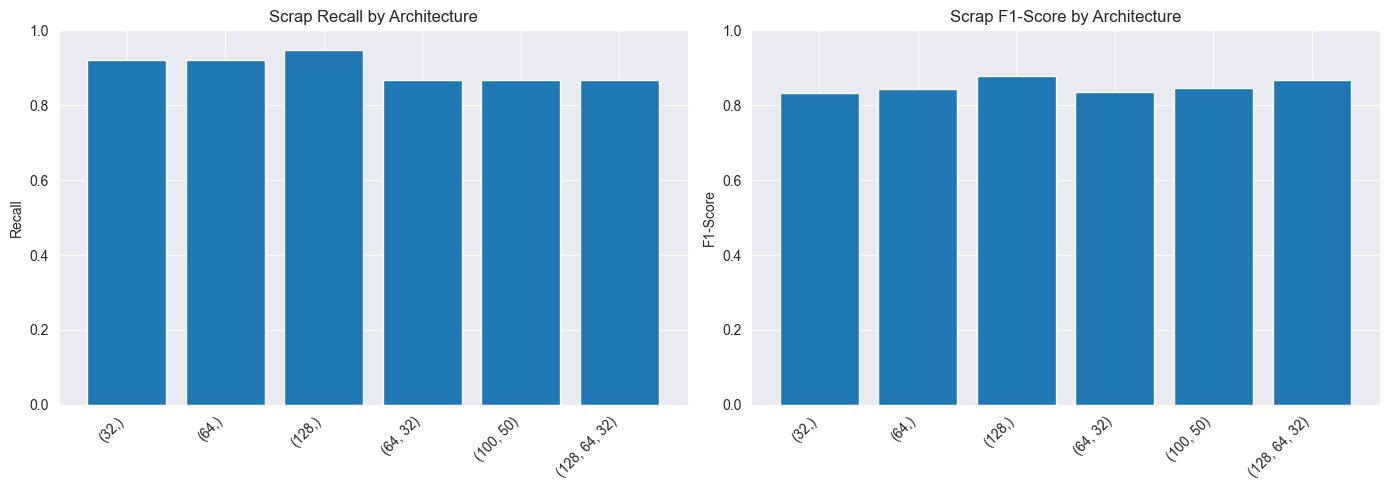

In [81]:
results_df = pd.DataFrame(results)
results_df['arch_label'] = results_df['architecture'].astype(str)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(range(len(results_df)), results_df['scrap_recall'])
ax[0].set_xticks(range(len(results_df)))
ax[0].set_xticklabels(results_df['arch_label'], rotation=45, ha='right')
ax[0].set_ylabel('Recall')
ax[0].set_title('Scrap Recall by Architecture')
ax[0].set_ylim([0, 1])

ax[1].bar(range(len(results_df)), results_df['scrap_f1'])
ax[1].set_xticks(range(len(results_df)))
ax[1].set_xticklabels(results_df['arch_label'], rotation=45, ha='right')
ax[1].set_ylabel('F1-Score')
ax[1].set_title('Scrap F1-Score by Architecture')
ax[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

#### Training History (Loss Curve) ####

Visualize how the model's loss decreased during training.

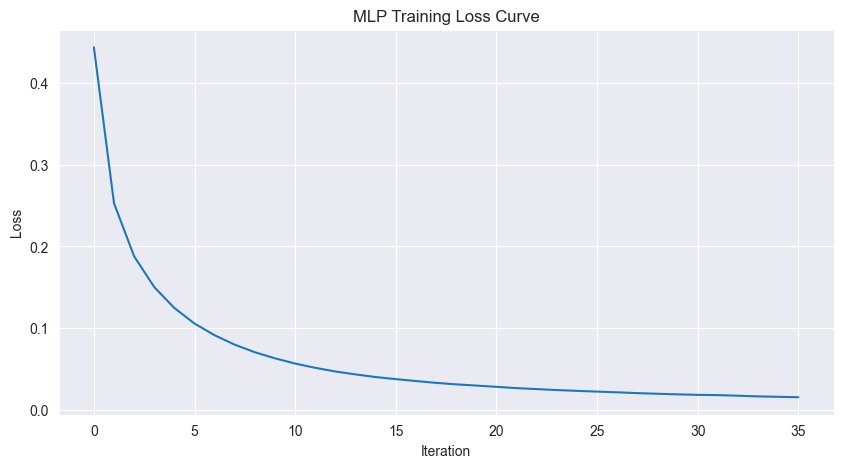

Final training loss: 0.0156
Number of iterations: 36


In [82]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_balanced.loss_curve_)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Training Loss Curve')
plt.grid(True)
plt.show()

print(f"Final training loss: {mlp_balanced.loss_:.4f}")
print(f"Number of iterations: {mlp_balanced.n_iter_}")

#### Threshold optimization ####

In [83]:
y_proba = mlp_balanced.predict_proba(X_test_scaled)[:, 1]
# [:, 1] gets probability of class 1 like scrapos

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_thresh, output_dict=True)
    results.append({
        'threshold': threshold,
        'f1_score': report['1']['f1-score'],
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'accuracy': report['accuracy']
    })

    print(f"Threshold: {threshold:.2f} | F1: {report['1']['f1-score']:.3f} | "
          f"Precision: {report['1']['precision']:.3f} | Recall: {report['1']['recall']:.3f}")

# Convert to DataFrame for easy analysis
results_df = pd.DataFrame(results)

# Find best threshold
best_idx = results_df['f1_score'].idxmax()
best_threshold = results_df.loc[best_idx, 'threshold']
best_f1 = results_df.loc[best_idx, 'f1_score']

print(f"best threshold = {best_threshold:.2f} with F1 score: {best_f1:.3f}")

Threshold: 0.10 | F1: 0.791 | Precision: 0.679 | Recall: 0.947
Threshold: 0.15 | F1: 0.837 | Precision: 0.750 | Recall: 0.947
Threshold: 0.20 | F1: 0.857 | Precision: 0.783 | Recall: 0.947
Threshold: 0.25 | F1: 0.857 | Precision: 0.783 | Recall: 0.947
Threshold: 0.30 | F1: 0.857 | Precision: 0.783 | Recall: 0.947
Threshold: 0.35 | F1: 0.857 | Precision: 0.783 | Recall: 0.947
Threshold: 0.40 | F1: 0.857 | Precision: 0.783 | Recall: 0.947
Threshold: 0.45 | F1: 0.867 | Precision: 0.800 | Recall: 0.947
Threshold: 0.50 | F1: 0.878 | Precision: 0.818 | Recall: 0.947
Threshold: 0.55 | F1: 0.889 | Precision: 0.837 | Recall: 0.947
Threshold: 0.60 | F1: 0.846 | Precision: 0.825 | Recall: 0.868
Threshold: 0.65 | F1: 0.846 | Precision: 0.825 | Recall: 0.868
Threshold: 0.70 | F1: 0.846 | Precision: 0.825 | Recall: 0.868
Threshold: 0.75 | F1: 0.868 | Precision: 0.868 | Recall: 0.868
Threshold: 0.80 | F1: 0.880 | Precision: 0.892 | Recall: 0.868
Threshold: 0.85 | F1: 0.877 | Precision: 0.914 | Recall

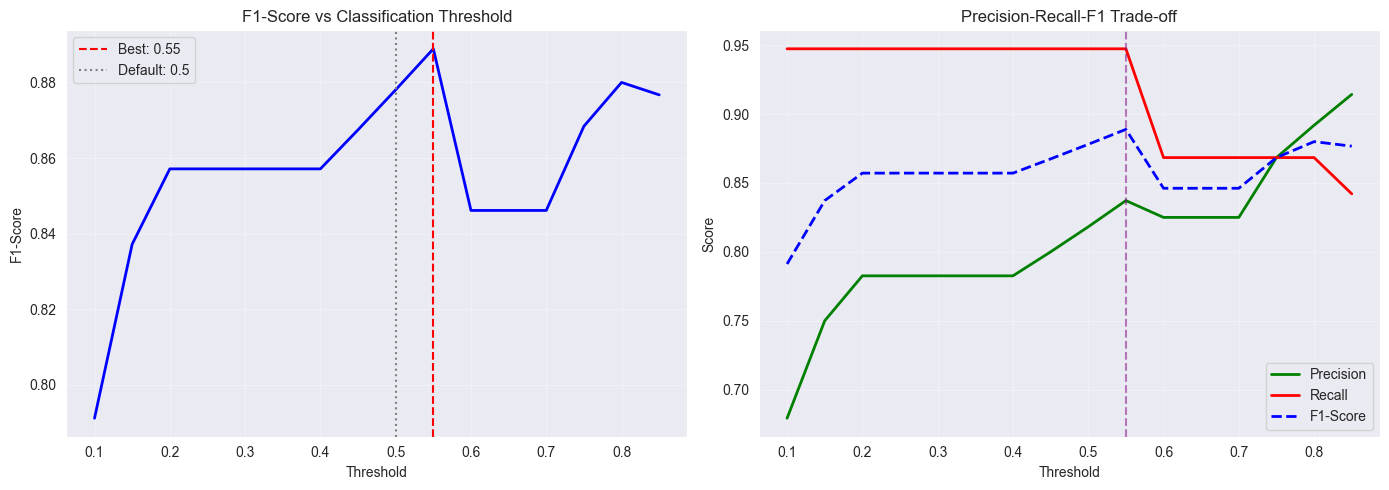

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1-Score vs Threshold
axes[0].plot(results_df['threshold'], results_df['f1_score'], 'b-', linewidth=2)
axes[0].axvline(best_threshold, color='r', linestyle='--', label=f'Best: {best_threshold:.2f}')
axes[0].axvline(0.5, color='gray', linestyle=':', label='Default: 0.5')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('F1-Score vs Classification Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision-Recall Trade-off
axes[1].plot(results_df['threshold'], results_df['precision'], 'g-', label='Precision', linewidth=2)
axes[1].plot(results_df['threshold'], results_df['recall'], 'r-', label='Recall', linewidth=2)
axes[1].plot(results_df['threshold'], results_df['f1_score'], 'b--', label='F1-Score', linewidth=2)
axes[1].axvline(best_threshold, color='purple', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision-Recall-F1 Trade-off')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Performance with optimized threshold
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       933
           1       0.84      0.95      0.89        38

    accuracy                           0.99       971
   macro avg       0.92      0.97      0.94       971
weighted avg       0.99      0.99      0.99       971

Stored 'mlp_optimized' (dict)


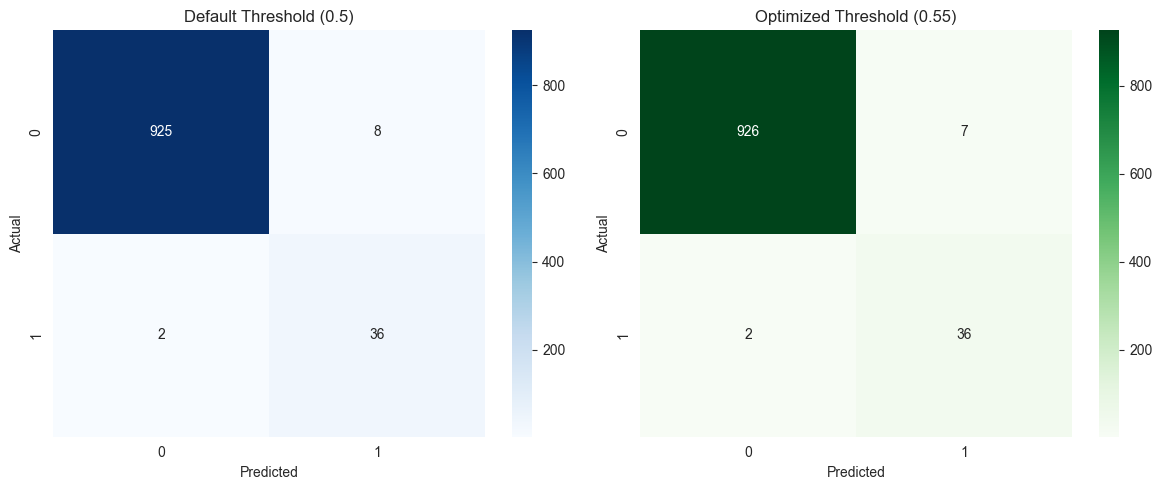

In [85]:
y_pred_optimized = (y_proba >= best_threshold).astype(int)

print("Performance with optimized threshold")
mlp_optimized = classification_report(y_test, y_pred_optimized, output_dict=True)
print(classification_report(y_test, y_pred_optimized))
%store mlp_optimized

# confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_default = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Default Threshold (0.5)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_optimized = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Optimized Threshold ({best_threshold:.2f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()
